# 🧩 Malaria Image Preprocessing – Optimized for Logistic Regression

In [50]:
from sklearn.preprocessing import StandardScaler, label_binarize

# models
from sklearn.cluster import KMeans

# evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, mean_squared_error,roc_curve, roc_auc_score


In [3]:
import cv2
import os
import numpy as np
from tqdm import tqdm   # to see the time progrese
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
import os
import cv2
import numpy as np

dataset_path = r"C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset"
folders = ["Parasitized", "Uninfected"] 

processed_images = {}

for folder_name in folders:
    folder_path = os.path.join(dataset_path, folder_name)
    processed_images[folder_name] = []   # أنشئي قائمة لهذا الفولدر

    print(f"\n📂 Loading images from: {folder_name}")

    for filename in os.listdir(folder_path):

        file_path = os.path.join(folder_path, filename)

        # Skip non-images
        if not (filename.lower().endswith(".png") or filename.lower().endswith(".jpg") or filename.lower().endswith(".jpeg")):
            continue

        img = cv2.imread(file_path)

        if img is None:
            print(f"⚠️ Could not load {filename}")
            continue

        # ---- Processing for unsupervised ----
        img = cv2.resize(img, (128, 128))         # تثبيت الحجم
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) 
        flat = gray.flatten()                     # تحويل 2D → 1D

        processed_images[folder_name].append(flat)




# Flatten all lists from dictionary into one list
all_images = []

for folder_name in processed_images:
    all_images.extend(processed_images[folder_name])  # extend عشان يحط كل الصور في قائمة واحدة

# Convert to numpy array
X = np.array(all_images)

print("\n✅ Dataset ready for unsupervised learning!")
print("Shape:", X.shape)



📂 Loading images from: Parasitized

📂 Loading images from: Uninfected

✅ Dataset ready for unsupervised learning!
Shape: (12, 16384)


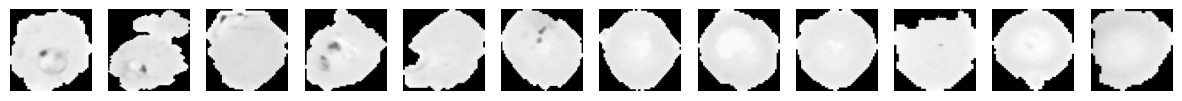

In [44]:
plt.figure(figsize=(15, 3))
for i in range(12):
    plt.subplot(1, 12, i + 1)
    plt.imshow(all_images[i].reshape(128, 128), cmap='gray')
    plt.axis('off')

plt.show()

## **Step 2: Resize Images**

In [3]:
target_size = (64, 64)

# Resize كل الصور باستخدام OpenCV
resized_images = [cv2.resize(img, target_size) for img in images]

# تحويل لمصفوفة numpy float32 مع normalize [0,1]
X = np.array(resized_images, dtype='float32') / 255.0
y = np.array(labels, dtype='int')

print("All images resized to:", target_size)
print("X shape:", X.shape, "y shape:", y.shape)

All images resized to: (64, 64)
X shape: (27558, 64, 64, 3) y shape: (27558,)


In [41]:
X.dtype

dtype('float32')

In [42]:
# تحويل لمصفوفة numpy float32 مع normalize [0,1]
X = np.array(X, dtype='float32') / 255.0

print("X shape:", X.shape)

X shape: (12, 16384)


In [43]:
print("Min:", X[0].min())
print("Max:", X[0].max())

Min: 0.0
Max: 0.002983468


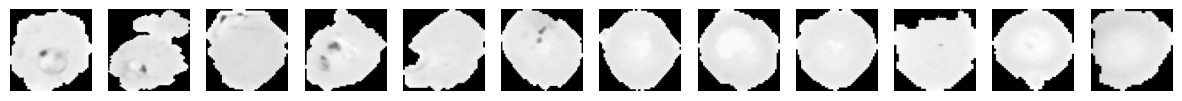

In [ ]:
plt.figure(figsize=(15, 3))
for i in range(12):
    plt.subplot(1, 12, i + 1)
    plt.imshow(all_images[i].reshape(128, 128), cmap='gray')
    plt.axis('off')

plt.show()

## **Step 3: Convert to Grayscale (Optional but Recommended)**

In [48]:
# تحويل كل الصور لـ grayscale فقط
gray_images = [cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in resized_images]

print("All images converted to grayscale.")
print("gray_images list length:", len(gray_images))

NameError: name 'resized_images' is not defined

## **Step 4: Normalize Pixel Values**

In [ ]:
# normalize القيم [0,1]
normalized_images = [np.array(img, dtype='float32') / 255.0 for img in gray_images]

# تحويل لمصفوفة numpy
X_gray = np.array(normalized_images, dtype='float32')

print("Pixel values normalized to range 0-1.")
print("X_gray shape:", X_gray.shape)

Pixel values normalized to range 0-1.
X_gray shape: (12, 16384)


## **Step 5: Flatten Images**
-  Logistic Regression expects a vector, not a 2D image.
- Flatten each image (e.g., 64x64 → 4096 features).

In [ ]:
# Flatten كل الصور
X_flat = X_gray.reshape(X_gray.shape[0], -1)  # 27558 × 4096

print("Images flattened. Each image shape:", X_flat[0].shape)

Images flattened. Each image shape: (4096,)


## **Step 6: Build X and Y**
- X = all flattened images
- Y = labels

In [8]:
X = X_flat.astype('float32')
y = np.array(labels, dtype='int')

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (27558, 4096)
y shape: (27558,)


In [59]:
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

print(labels[:20])

[1 0 1 0 0 1 1 1 1 1 1 1]
